# Test time PDFs

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import astropy.time
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import momenta
from momenta.io import Parameters, NuDetector, Parameters, PointSource
from momenta.io import neutrinos_irfs as irfs

/home/craab/Software/momenta/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from astropy.time import Time, TimeDelta
from momenta.io import transient
from momenta.io import neutrinos

In [3]:
import abc
import astropy.coordinates
import astropy.time
import healpy as hp
import numpy as np

from astropy.units import deg
from scipy.integrate import quad
from scipy.interpolate import interp1d, RegularGridInterpolator
from scipy.stats import norm
from typing import Callable

from momenta.utils.flux import Component

import numpy as np
import unittest

import momenta.io.neutrinos as nu
import momenta.io.neutrinos_irfs as irfs
import momenta.utils.flux as flux


In [4]:
# a lightcurve in MJD
lc = flux.BinnedLightcurve(np.array([5e4 - 1, 5e4, 5e4 + 1]), np.array([0, 1e36]))
# can be set for a flux component in absolute time
f = flux.FixedPowerLaw(emin=1, emax=100, gamma=2)
f.set_lightcurve(lc)

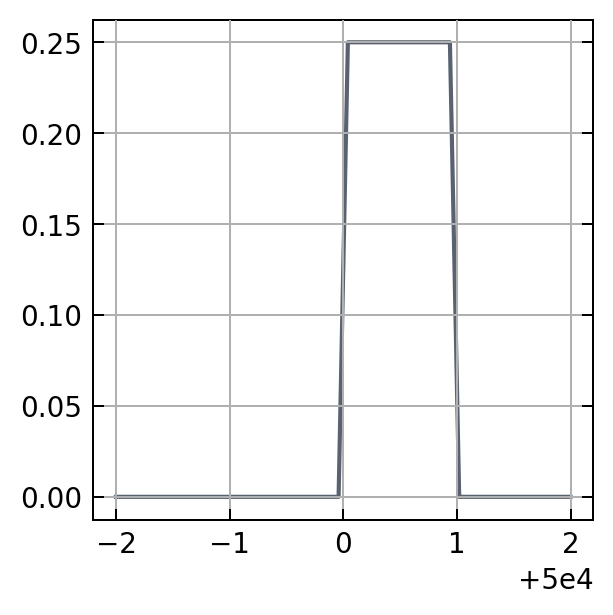

In [5]:
# that lets it get evaluated as a flux
mjdspace = np.linspace(5e4-2, 5e4+2)
plt.plot(mjdspace, f.evaluate(energy=2*np.ones_like(mjdspace), time=Time(mjdspace, format="mjd")))

In [6]:
# and this PDF class evaluates it as a PDF
time_signal = irfs.AbsoluteTimeSignal()

In [7]:
# the events then need an MJD as well (for now)
ev = neutrinos.NuEvent(dt=0,ra=100,dec=20,energy=1,sigma=1, mjd=50000 + 0.5)
time_signal(ev, f)

1.0

In [8]:
ev.mjd

50000.5

In [9]:
# Set up an analysis
import momenta.utils.flux as flux
from momenta.io import GW, NuDetector, SuperNuDetector, Parameters
from momenta.io.neutrinos import BackgroundFixed, BackgroundPoisson
from momenta.io.neutrinos_irfs import EffectiveAreaAllSky
from momenta.stats.run import run_ultranest
from momenta.stats.constraints import get_limits

In [10]:

parameters = Parameters("../examples/input_files/config.yaml")

In [11]:
grb1 = PointSource(100, 20, 0, name="GRB1") # coincident with the event
grb1.set_distance(60)

In [12]:
det1 = NuDetector(
    {
        "name": "Detector1",
        "samples": ["SampleA"],
    }
)

[2026-05-10 23:36:13,628:momenta:INFO] [NuDetector] Object is loaded from a dictionary object.


In [13]:
from momenta.io.neutrinos_irfs import EffectiveAreaAllSky, IsotropicBackground, VonMisesSignal, AbsoluteTimeSignal, TimeBackground

In [14]:
# the PDF classes to use have to be set manually
det1.set_pdfs([
    {
        "sig_ang": VonMisesSignal(),
        "bkg_ang": IsotropicBackground(),
        "sig_time": AbsoluteTimeSignal(),
        "bkg_time": TimeBackground(10), # 10 days but it's arbitray units for now
        }])

In [15]:
# Set livetime array now, with just one period
grl = np.array([(5e4 -5, 5e4 + 5)], dtype=[('start', float), ('stop', float)])
det1.set_livetimes(irfs.Livetime(grl_array=grl))
# (there is some redundancy here with setting the background)
# default it has self.livetime = NoLivetime which assumes complete coverage

In [16]:
# Custom effective area that is constant over the full sky and just depends on energy
class EffAreaDet1(EffectiveAreaAllSky):
    def evaluate(self, energy, ipix, nside):
        return (energy / 100) ** 2 * np.exp(-energy / 3000)

det1.set_effective_areas([EffAreaDet1()])

In [17]:
bkg1 = [BackgroundPoisson(10, 20)]
nobs1 = [1]

# Filling values to the detector objects
det1.set_observations(nobs1, bkg1)


In [18]:
ev.time

<Time object: scale='utc' format='mjd' value=50000.5>

In [19]:
det1.set_events([[ev]])

In [20]:
# the component has to be contained in a flux
parameters.flux = flux.FluxTimeDependentFixedPowerLaw(lc, 1, 100, gamma=2)

In [21]:
# and then we can run!
model, result = run_ultranest(det1, grb1, parameters)

In [22]:
result

{'niter': 4776,
 'logz': -11.539240000007926,
 'logzerr': 0.27552564060139967,
 'logz_bs': -11.533913152217183,
 'logz_single': -11.539240000007926,
 'logzerr_tail': 0.03049747141024106,
 'logzerr_bs': 0.27383258182034,
 'ess': 1337.8415693943532,
 'H': 6.8818373108079145,
 'Herr': 0.11851495052762512,
 'posterior': {'mean': [3.850655892841576e+54, 0.0],
  'stdev': [2.768442156274075e+54, 0.0],
  'median': [3.228754857530686e+54, 0.0],
  'errlo': [1.2800934961595223e+54, 0.0],
  'errup': [6.41390440098746e+54, 0.0],
  'information_gain_bits': [4.14647919764959, -5.173389464284599]},
 'weighted_samples': {'upoints': array([[9.99616727e-01, 2.69173553e-01],
         [9.97282194e-01, 7.43991952e-01],
         [9.94464191e-01, 6.23952706e-01],
         ...,
         [1.82462214e-04, 7.10481428e-01],
         [1.82744555e-04, 2.58221912e-01],
         [1.82516067e-04, 1.64396076e-04]]),
  'points': {'itoy': array([0., 0., 0., ..., 0., 0., 0.]),
   'etot0': array([9.99616727e+57, 9.97282194e

In [23]:
print("Limit on Etot using GRB1 =", get_limits(result)["etot0"])

Limit on Etot using GRB1 = 7.66957049845196e+54
